# 02 - CPA baseline: full-key recovery (runs from saved traces)

**No hardware required.** This is the clean-machine reproduction step: it loads the
saved fixed-key `.npz` and runs Correlation Power Analysis (Hamming-weight of the first-round
S-box output) to recover the full 16-byte AES key, proving the leak before any neural network
is trusted. It is not hardware-gated.

Input: `traces/unprotected_fixedkey.npz` (from `01_capture.ipynb` on approved
hardware, or the published traces).
Output: `results/cpa_aes-unprotected.json` (recovered key + `traces_to_rank0`) and
the CPA correlation-peak + GE-vs-traces figures in `results/`.

In [ ]:
import os, pathlib
import numpy as np
import matplotlib.pyplot as plt
from dlsca import seeds, dataset, cpa, attack

# Run from the repo root so relative paths (traces/, results/) resolve no matter where the
# kernel was launched (nbconvert starts it in notebooks/). Walk up to the dir holding traces/.
_p = pathlib.Path.cwd()
for _cand in (_p, *_p.parents):
    if (_cand / "traces").is_dir() and (_cand / "src" / "dlsca").is_dir():
        os.chdir(_cand); break
print("cwd:", os.getcwd())

SEED = 0
seeds.set_all(SEED)  # deterministic GE orderings
DATASET = "unprotected_fixedkey"

In [2]:
# Load + validate the saved attack set (no hardware).
ts = dataset.load(DATASET)
report = dataset.validate(ts, sample=500)
print(report)
assert report["ok"], report["errors"]
known_key = ts.keys[0]  # fixed-key set: every row identical
print("known key:", bytes(known_key).hex())

{'ok': True, 'errors': [], 'checked_rows': 500, 'n_traces': 5000, 'fixed_key': True, 'role': 'fixed-key'}
known key: 000102030405060708090a0b0c0d0e0f


In [3]:
# Full CPA attack: per-byte HW-model correlation -> recovered key + GE curve + traces_to_rank0.
result = cpa.run(ts.traces, ts.plaintexts, known_key,
                 firmware="aes-unprotected", dataset=DATASET,
                 n_orderings=10, seed=SEED, with_ge=True)

recovered = bytes(result["recovered_key"]).hex()
known = bytes(result["known_key"]).hex()
print("known     key:", known)
print("recovered key:", recovered)
print("all 16 bytes rank 0:", all(result["correct"]))
print("traces_to_rank0 :", result["traces_to_rank0"])
assert recovered == known, "CPA did not recover the full key"

known     key: 000102030405060708090a0b0c0d0e0f
recovered key: 000102030405060708090a0b0c0d0e0f
all 16 bytes rank 0: True
traces_to_rank0 : 100


In [ ]:
# Persist the AttackResult artifact.
path = attack.save_result(result)  # -> results/cpa_aes-unprotected.json
print("wrote", path)

In [ ]:
# Figure 1: CPA correlation peak for byte 0. Correct candidate stands out from the rest.
corr0 = cpa.byte_correlations(ts.traces, ts.plaintexts, target_byte=0)  # (256, S)
kb0 = int(known_key[0])
plt.figure(figsize=(9, 3))
plt.plot(corr0.T, color="0.8", lw=0.4)
plt.plot(corr0[kb0], color="C3", lw=1.2, label=f"correct candidate 0x{kb0:02x}")
plt.title("CPA correlation vs sample (byte 0): correct key candidate peaks")
plt.xlabel("sample"); plt.ylabel("|correlation|"); plt.legend()
plt.tight_layout(); plt.savefig("results/cpa_corr_peak.png", dpi=120); plt.show()

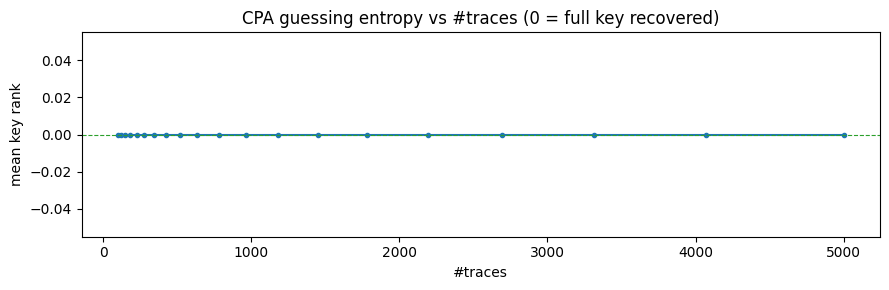

In [6]:
# Figure 2: guessing entropy (mean full-key rank) vs #traces.
plt.figure(figsize=(9, 3))
plt.plot(result["ge_trace_counts"], result["ge_curve"], marker="o", ms=3)
plt.axhline(0, color="C2", ls="--", lw=0.8)
plt.title("CPA guessing entropy vs #traces (0 = full key recovered)")
plt.xlabel("#traces"); plt.ylabel("mean key rank")
plt.tight_layout(); plt.savefig("results/cpa_ge_curve.png", dpi=120); plt.show()

**Reproduction check:** re-running this notebook top-to-bottom from the saved `.npz`
alone, under the fixed seed, must recover the identical key on any clean machine.